In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!rm -rf /content/dataset
!mkdir -p /content/dataset

!unzip -q "/content/drive/MyDrive/aug_data.zip" -d "/content/dataset"

In [4]:
from pathlib import Path

dataset_path = Path("/content/dataset")

for path in dataset_path.rglob("*"):
    if path.is_dir():
        files = [f for f in path.iterdir() if f.is_file()]
        print(f"{path} → {len(files)} files")

/content/dataset/aug_data → 0 files
/content/dataset/aug_data/masks → 2940 files
/content/dataset/aug_data/images → 2940 files


In [5]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: False


In [6]:
from pathlib import Path

dataset_path = Path("/content/dataset")

for path in dataset_path.iterdir():
    print(path)

/content/dataset/aug_data


In [7]:
for path in dataset_path.rglob("*"):
    if path.is_dir():
        print("📁", path)

📁 /content/dataset/aug_data
📁 /content/dataset/aug_data/masks
📁 /content/dataset/aug_data/images


In [8]:
for path in dataset_path.rglob("*"):
    if path.is_dir():
        files = [f for f in path.iterdir() if f.is_file()]
        print(f"{path} → {len(files)} files")

/content/dataset/aug_data → 0 files
/content/dataset/aug_data/masks → 2940 files
/content/dataset/aug_data/images → 2940 files


In [9]:
from pathlib import Path

image_dir = Path("/content/dataset/aug_data/images")
mask_dir = Path("/content/dataset/aug_data/masks")

image_files = sorted([
    p for p in image_dir.iterdir()
    if p.is_file()
])

mask_files = sorted([
    p for p in mask_dir.iterdir()
    if p.is_file()
])

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

print("\nFirst 10 images:")
for p in image_files[:10]:
    print(p.name)

print("\nFirst 10 masks:")
for p in mask_files[:10]:
    print(p.name)

Number of images: 2940
Number of masks: 2940

First 10 images:
00000_0.jpg
00000_1.jpg
00000_2.jpg
00000_3.jpg
00000_4.jpg
00001_0.jpg
00001_1.jpg
00001_2.jpg
00001_3.jpg
00001_4.jpg

First 10 masks:
00000_0.png
00000_1.png
00000_2.png
00000_3.png
00000_4.png
00001_0.png
00001_1.png
00001_2.png
00001_3.png
00001_4.png


In [10]:
for img, mask in zip(image_files[:20], mask_files[:20]):
    print(f"{img.name}  <-->  {mask.name}")

00000_0.jpg  <-->  00000_0.png
00000_1.jpg  <-->  00000_1.png
00000_2.jpg  <-->  00000_2.png
00000_3.jpg  <-->  00000_3.png
00000_4.jpg  <-->  00000_4.png
00001_0.jpg  <-->  00001_0.png
00001_1.jpg  <-->  00001_1.png
00001_2.jpg  <-->  00001_2.png
00001_3.jpg  <-->  00001_3.png
00001_4.jpg  <-->  00001_4.png
00002_0.jpg  <-->  00002_0.png
00002_1.jpg  <-->  00002_1.png
00002_2.jpg  <-->  00002_2.png
00002_3.jpg  <-->  00002_3.png
00002_4.jpg  <-->  00002_4.png
00003_0.jpg  <-->  00003_0.png
00003_1.jpg  <-->  00003_1.png
00003_2.jpg  <-->  00003_2.png
00003_3.jpg  <-->  00003_3.png
00003_4.jpg  <-->  00003_4.png


In [11]:
import cv2
import matplotlib.pyplot as plt

img_path = image_files[0]
mask_path = mask_files[0]

image = cv2.imread(str(img_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

print("Image:", img_path.name)
print("Mask:", mask_path.name)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

print("Mask min:", mask.min())
print("Mask max:", mask.max())

print("Unique mask values:")
print(sorted(set(mask.flatten()))[:30])

Image: 00000_0.jpg
Mask: 00000_0.png
Image shape: (235, 326, 3)
Mask shape: (235, 326)
Mask min: 0
Mask max: 38
Unique mask values:
[np.uint8(0), np.uint8(38)]


In [12]:
image_stems = {p.stem for p in image_files}
mask_stems = {p.stem for p in mask_files}

print("Images without masks:",
      image_stems - mask_stems)

print("Masks without images:",
      mask_stems - image_stems)

Images without masks: set()
Masks without images: set()


In [13]:
import cv2
import matplotlib.pyplot as plt

img_path = image_files[0]
mask_path = mask_files[0]

image = cv2.imread(str(img_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(
    str(mask_path),
    cv2.IMREAD_GRAYSCALE
)

print("Image:", img_path.name)
print("Mask:", mask_path.name)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

print("Mask minimum:", mask.min())
print("Mask maximum:", mask.max())

print("Unique mask values:",
      sorted(set(mask.flatten())))

Image: 00000_0.jpg
Mask: 00000_0.png
Image shape: (235, 326, 3)
Mask shape: (235, 326)
Mask minimum: 0
Mask maximum: 38
Unique mask values: [np.uint8(0), np.uint8(38)]


In [14]:
binary_mask = (mask > 0).astype("uint8")

print("Original values:",
      sorted(set(mask.flatten())))

print("Binary values:",
      sorted(set(binary_mask.flatten())))

Original values: [np.uint8(0), np.uint8(38)]
Binary values: [np.uint8(0), np.uint8(1)]


In [15]:
binary_mask = (mask > 0).astype("uint8")

print("Original values:",
      sorted(set(mask.flatten())))

print("Binary values:",
      sorted(set(binary_mask.flatten())))

Original values: [np.uint8(0), np.uint8(38)]
Binary values: [np.uint8(0), np.uint8(1)]


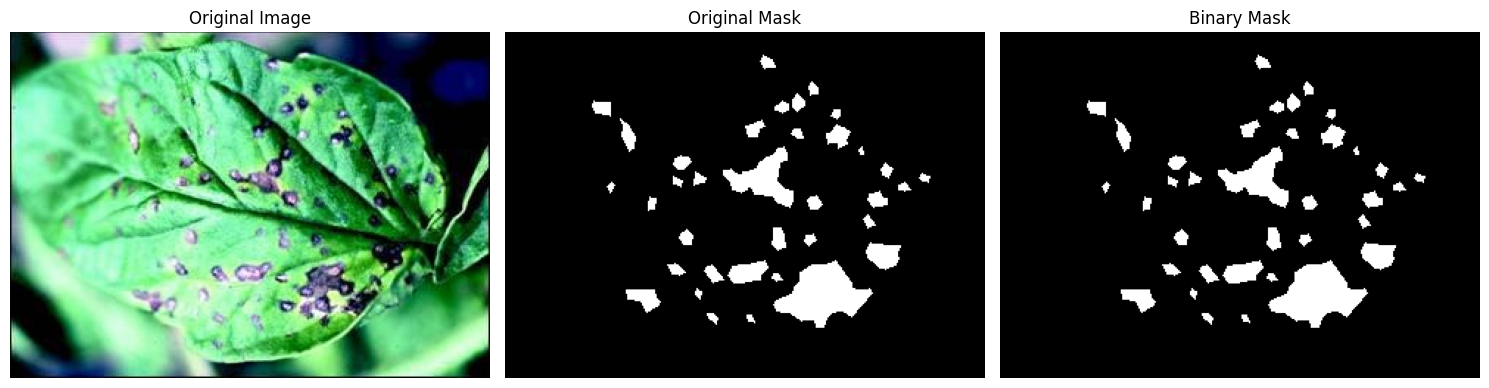

In [16]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Original Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(binary_mask, cmap="gray")
plt.title("Binary Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

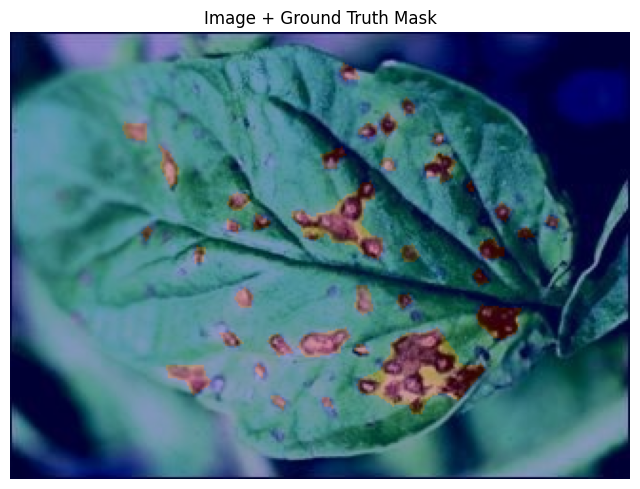

In [17]:
plt.figure(figsize=(8, 6))

plt.imshow(image)
plt.imshow(binary_mask, cmap="jet", alpha=0.4)

plt.title("Image + Ground Truth Mask")
plt.axis("off")

plt.show()

In [18]:
for img, mask in zip(image_files[:20], mask_files[:20]):
    print(f"{img.name}  <-->  {mask.name}")

00000_0.jpg  <-->  00000_0.png
00000_1.jpg  <-->  00000_1.png
00000_2.jpg  <-->  00000_2.png
00000_3.jpg  <-->  00000_3.png
00000_4.jpg  <-->  00000_4.png
00001_0.jpg  <-->  00001_0.png
00001_1.jpg  <-->  00001_1.png
00001_2.jpg  <-->  00001_2.png
00001_3.jpg  <-->  00001_3.png
00001_4.jpg  <-->  00001_4.png
00002_0.jpg  <-->  00002_0.png
00002_1.jpg  <-->  00002_1.png
00002_2.jpg  <-->  00002_2.png
00002_3.jpg  <-->  00002_3.png
00002_4.jpg  <-->  00002_4.png
00003_0.jpg  <-->  00003_0.png
00003_1.jpg  <-->  00003_1.png
00003_2.jpg  <-->  00003_2.png
00003_3.jpg  <-->  00003_3.png
00003_4.jpg  <-->  00003_4.png


In [19]:
from pathlib import Path

# Get original IDs from filenames
original_ids = set()

for img_path in image_files:
    # Example: 00000_3.jpg → 00000
    original_id = img_path.stem.rsplit("_", 1)[0]
    original_ids.add(original_id)

print("Total augmented images:", len(image_files))
print("Number of original image groups:", len(original_ids))

print("\nFirst 20 original IDs:")
print(sorted(original_ids)[:20])

Total augmented images: 2940
Number of original image groups: 588

First 20 original IDs:
['00000', '00001', '00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009', '00010', '00011', '00012', '00013', '00014', '00015', '00016', '00017', '00018', '00019']


In [20]:
from collections import Counter

group_counts = Counter()

for img_path in image_files:
    original_id = img_path.stem.rsplit("_", 1)[0]
    group_counts[original_id] += 1

print("Number of groups:", len(group_counts))

print("\nNumber of images per group:")
print(Counter(group_counts.values()))

Number of groups: 588

Number of images per group:
Counter({5: 588})


In [21]:
group_id = "00000"

group_images = sorted([
    p for p in image_files
    if p.stem.rsplit("_", 1)[0] == group_id
])

group_masks = sorted([
    p for p in mask_files
    if p.stem.rsplit("_", 1)[0] == group_id
])

print("Images:")
for p in group_images:
    print(p.name)

print("\nMasks:")
for p in group_masks:
    print(p.name)

Images:
00000_0.jpg
00000_1.jpg
00000_2.jpg
00000_3.jpg
00000_4.jpg

Masks:
00000_0.png
00000_1.png
00000_2.png
00000_3.png
00000_4.png


In [22]:
original_ids = set()

for img_path in image_files:
    original_id = img_path.stem.rsplit("_", 1)[0]
    original_ids.add(original_id)

print("Total augmented images:", len(image_files))
print("Number of original image groups:", len(original_ids))

Total augmented images: 2940
Number of original image groups: 588


In [23]:
from collections import Counter

group_counts = Counter()

for img_path in image_files:
    original_id = img_path.stem.rsplit("_", 1)[0]
    group_counts[original_id] += 1

print(Counter(group_counts.values()))

Counter({5: 588})


In [24]:
group_id = "00000"

for p in sorted(image_files):
    if p.stem.rsplit("_", 1)[0] == group_id:
        print(p.name)

00000_0.jpg
00000_1.jpg
00000_2.jpg
00000_3.jpg
00000_4.jpg


In [25]:
from sklearn.model_selection import train_test_split

# Convert set to sorted list for reproducibility
original_ids = sorted(original_ids)

# First: 70% train, 30% temporary
train_ids, temp_ids = train_test_split(
    original_ids,
    test_size=0.30,
    random_state=42
)

# Split remaining 30% equally into validation and test
val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42
)

print("Train groups:", len(train_ids))
print("Validation groups:", len(val_ids))
print("Test groups:", len(test_ids))

Train groups: 411
Validation groups: 88
Test groups: 89


In [26]:
print("Train ∩ Validation:",
      len(set(train_ids) & set(val_ids)))

print("Train ∩ Test:",
      len(set(train_ids) & set(test_ids)))

print("Validation ∩ Test:",
      len(set(val_ids) & set(test_ids)))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [27]:
def get_files_for_groups(group_ids, image_files, mask_files):
    group_ids = set(group_ids)

    selected_images = []
    selected_masks = []

    for img_path in image_files:
        group_id = img_path.stem.rsplit("_", 1)[0]

        if group_id in group_ids:
            selected_images.append(img_path)

    for mask_path in mask_files:
        group_id = mask_path.stem.rsplit("_", 1)[0]

        if group_id in group_ids:
            selected_masks.append(mask_path)

    return sorted(selected_images), sorted(selected_masks)


train_images, train_masks = get_files_for_groups(
    train_ids,
    image_files,
    mask_files
)

val_images, val_masks = get_files_for_groups(
    val_ids,
    image_files,
    mask_files
)

test_images, test_masks = get_files_for_groups(
    test_ids,
    image_files,
    mask_files
)

print("Train:")
print("  Images:", len(train_images))
print("  Masks :", len(train_masks))

print("\nValidation:")
print("  Images:", len(val_images))
print("  Masks :", len(val_masks))

print("\nTest:")
print("  Images:", len(test_images))
print("  Masks :", len(test_masks))

Train:
  Images: 2055
  Masks : 2055

Validation:
  Images: 440
  Masks : 440

Test:
  Images: 445
  Masks : 445


In [28]:
print("Some TRAIN groups:")
print(train_ids[:10])

print("\nSome VALIDATION groups:")
print(val_ids[:10])

print("\nSome TEST groups:")
print(test_ids[:10])

Some TRAIN groups:
['00368', '00298', '00382', '00245', '00523', '00069', '00443', '00531', '00272', '00196']

Some VALIDATION groups:
['00274', '00340', '00550', '00353', '00079', '00077', '00335', '00022', '00488', '00104']

Some TEST groups:
['00182', '00524', '00496', '00473', '00420', '00209', '00153', '00587', '00517', '00033']


In [29]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.11.0+cpu
CUDA: False


In [30]:
class LeafSegmentationDataset(Dataset):

    def __init__(self, image_paths, mask_paths, image_size=(256, 256)):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.image_size = image_size

        assert len(self.image_paths) == len(self.mask_paths), \
            "Number of images and masks must be equal"

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        # -----------------------------
        # 1. Get image and mask paths
        # -----------------------------
        image_path = self.image_paths[index]
        mask_path = self.mask_paths[index]

        # -----------------------------
        # 2. Read image
        # -----------------------------
        image = cv2.imread(str(image_path))

        # OpenCV loads images as BGR
        # Convert BGR → RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # -----------------------------
        # 3. Read mask
        # -----------------------------
        mask = cv2.imread(
            str(mask_path),
            cv2.IMREAD_GRAYSCALE
        )

        # -----------------------------
        # 4. Resize image
        # -----------------------------
        image = cv2.resize(
            image,
            self.image_size,
            interpolation=cv2.INTER_AREA
        )

        # -----------------------------
        # 5. Resize mask
        # -----------------------------
        mask = cv2.resize(
            mask,
            self.image_size,
            interpolation=cv2.INTER_NEAREST
        )

        # -----------------------------
        # 6. Convert mask to binary
        # -----------------------------
        mask = (mask > 0).astype(np.float32)

        # -----------------------------
        # 7. Normalize image
        # -----------------------------
        image = image.astype(np.float32) / 255.0

        # -----------------------------
        # 8. HWC → CHW
        # -----------------------------
        image = np.transpose(image, (2, 0, 1))

        # -----------------------------
        # 9. Convert to PyTorch tensors
        # -----------------------------
        image = torch.tensor(image, dtype=torch.float32)

        mask = torch.tensor(mask, dtype=torch.float32)

        # Add channel dimension to mask
        # 256 × 256
        #      ↓
        # 1 × 256 × 256
        mask = mask.unsqueeze(0)

        return image, mask

In [31]:
train_dataset = LeafSegmentationDataset(
    train_images,
    train_masks
)

val_dataset = LeafSegmentationDataset(
    val_images,
    val_masks
)

test_dataset = LeafSegmentationDataset(
    test_images,
    test_masks
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 2055
Validation dataset: 440
Test dataset: 445


In [32]:
image_tensor, mask_tensor = train_dataset[0]

print("Image tensor shape:", image_tensor.shape)
print("Mask tensor shape:", mask_tensor.shape)

print("Image dtype:", image_tensor.dtype)
print("Mask dtype:", mask_tensor.dtype)

print("Image min:", image_tensor.min().item())
print("Image max:", image_tensor.max().item())

print("Mask unique values:", torch.unique(mask_tensor))

Image tensor shape: torch.Size([3, 256, 256])
Mask tensor shape: torch.Size([1, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.float32
Image min: 0.0
Image max: 1.0
Mask unique values: tensor([0., 1.])


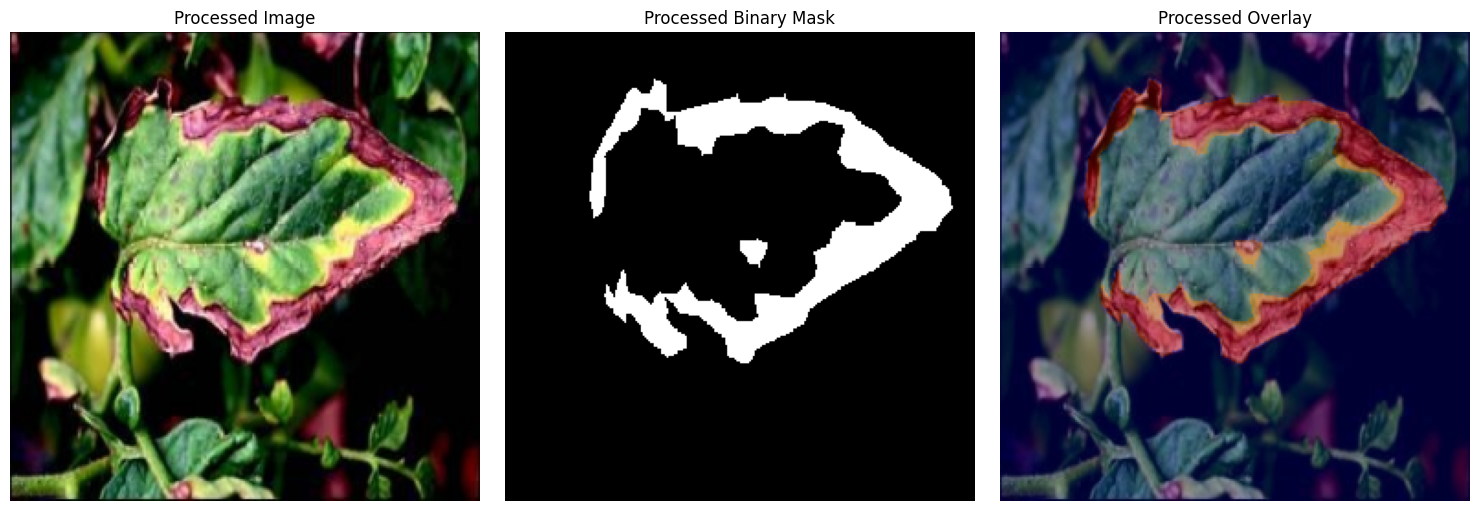

In [33]:
image_tensor, mask_tensor = train_dataset[0]

# Convert image back from CHW → HWC
image_display = image_tensor.permute(1, 2, 0).numpy()

# Remove mask channel
mask_display = mask_tensor.squeeze(0).numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_display)
plt.title("Processed Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_display, cmap="gray")
plt.title("Processed Binary Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image_display)
plt.imshow(mask_display, cmap="jet", alpha=0.4)
plt.title("Processed Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [35]:
images_batch, masks_batch = next(iter(train_loader))

print("Images batch shape:", images_batch.shape)
print("Masks batch shape:", masks_batch.shape)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Images batch shape: torch.Size([16, 3, 256, 256])
Masks batch shape: torch.Size([16, 1, 256, 256])


In [36]:
images_batch, masks_batch = next(iter(train_loader))

print("Images:", images_batch.shape)
print("Masks :", masks_batch.shape)

print("Image range:",
      images_batch.min().item(),
      "to",
      images_batch.max().item())

print("Mask values:",
      torch.unique(masks_batch))

Images: torch.Size([16, 3, 256, 256])
Masks : torch.Size([16, 1, 256, 256])
Image range: 0.0 to 1.0
Mask values: tensor([0., 1.])


# **Build U-Net**

Step 1.1 - Understand DoubleConv

In [37]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.double_conv = nn.Sequential(

            # First convolution
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            # Second convolution
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [38]:
double_conv = DoubleConv(
    in_channels=3,
    out_channels=64
)

In [39]:
output = double_conv(images_batch)

print("Input shape :", images_batch.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([16, 3, 256, 256])
Output shape: torch.Size([16, 64, 256, 256])


Step 1.2 — Build the Down Block

In [40]:
class Down(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.maxpool_conv = nn.Sequential(

            nn.MaxPool2d(kernel_size=2),

            DoubleConv(
                in_channels,
                out_channels
            )
        )

    def forward(self, x):
        return self.maxpool_conv(x)

In [41]:
down1 = Down(
    in_channels=64,
    out_channels=128
)

In [42]:
down_output = down1(output)

print("Input shape :", output.shape)
print("Output shape:", down_output.shape)

Input shape : torch.Size([16, 64, 256, 256])
Output shape: torch.Size([16, 128, 128, 128])


Step 1.3 — Build the Up Block

In [43]:
class Up(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

    def forward(self, x1, x2):

        x1 = self.up(x1)

        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)

In [44]:
up1 = Up(1024, 512)

x1 = torch.randn(16, 1024, 16, 16)
x2 = torch.randn(16, 512, 32, 32)

In [45]:
up_output = up1(x1, x2)

print("Decoder input :", x1.shape)
print("Skip input    :", x2.shape)
print("Output        :", up_output.shape)

Decoder input : torch.Size([16, 1024, 16, 16])
Skip input    : torch.Size([16, 512, 32, 32])
Output        : torch.Size([16, 512, 32, 32])


## Complete U-Net code

In [46]:
class UNet(nn.Module):

    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------

        self.inc = DoubleConv(
            n_channels,
            64
        )

        self.down1 = Down(
            64,
            128
        )

        self.down2 = Down(
            128,
            256
        )

        self.down3 = Down(
            256,
            512
        )

        self.down4 = Down(
            512,
            1024
        )

        # -------------------------
        # Decoder
        # -------------------------

        self.up1 = Up(
            1024,
            512
        )

        self.up2 = Up(
            512,
            256
        )

        self.up3 = Up(
            256,
            128
        )

        self.up4 = Up(
            128,
            64
        )

        # -------------------------
        # Final output layer
        # -------------------------

        self.outc = nn.Conv2d(
            64,
            n_classes,
            kernel_size=1
        )

    def forward(self, x):

        # -------------------------
        # Encoder
        # -------------------------

        x1 = self.inc(x)

        x2 = self.down1(x1)

        x3 = self.down2(x2)

        x4 = self.down3(x3)

        x5 = self.down4(x4)

        # -------------------------
        # Decoder + Skip Connections
        # -------------------------

        x = self.up1(x5, x4)

        x = self.up2(x, x3)

        x = self.up3(x, x2)

        x = self.up4(x, x1)

        # -------------------------
        # Final output
        # -------------------------

        logits = self.outc(x)

        return logits

In [47]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = UNet(
    n_channels=3,
    n_classes=1
).to(device)

print("Model created successfully!")
print("Device:", device)

Model created successfully!
Device: cpu


In [48]:
images_gpu = images_batch.to(device)

with torch.no_grad():
    predictions = model(images_gpu)

print("Input shape :", images_gpu.shape)
print("Output shape:", predictions.shape)

Input shape : torch.Size([16, 3, 256, 256])
Output shape: torch.Size([16, 1, 256, 256])


In [49]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is NOT available")

PyTorch version: 2.11.0+cpu
CUDA available: False
GPU is NOT available


In [50]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

False


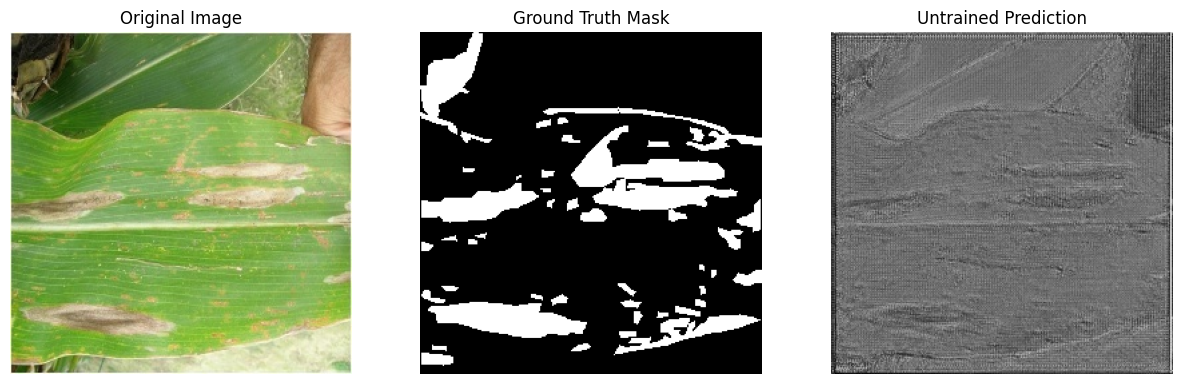

In [51]:
import matplotlib.pyplot as plt

# Take first image
image = images_batch[0]

# Take corresponding ground-truth mask
true_mask = masks_batch[0]

# Move prediction back to CPU
pred_mask = torch.sigmoid(predictions[0])

# Remove channel dimension
image = image.permute(1, 2, 0)

true_mask = true_mask.squeeze(0)
pred_mask = pred_mask.squeeze(0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(true_mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Untrained Prediction")
plt.axis("off")

plt.show()

# Step 1 — Create DiceLoss

In [52]:
class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):

        # Convert logits to probabilities
        predictions = torch.sigmoid(predictions)

        # Flatten everything
        predictions = predictions.view(-1)
        targets = targets.view(-1)

        # Calculate intersection
        intersection = (predictions * targets).sum()

        # Calculate Dice score
        dice = (
            2.0 * intersection + self.smooth
        ) / (
            predictions.sum()
            + targets.sum()
            + self.smooth
        )

        # Convert Dice score to Dice loss
        return 1 - dice

#Step 2 — Create combined BCE + Dice Loss

In [53]:
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, predictions, targets):
        bce_loss = self.bce(predictions, targets)
        dice_loss = self.dice(predictions, targets)

        total_loss = bce_loss + dice_loss

        return total_loss

# Step 3 — Create the loss function

In [54]:
criterion = BCEDiceLoss()

print("Loss function created successfully!")

Loss function created successfully!


# Step 4 — Test the loss function

In [55]:
model.eval()

images_batch, masks_batch = next(iter(train_loader))

images_batch = images_batch.to(device)
masks_batch = masks_batch.to(device)

with torch.no_grad():
    predictions = model(images_batch)

loss = criterion(predictions, masks_batch)

print("Prediction shape:", predictions.shape)
print("Mask shape:", masks_batch.shape)
print("Loss:", loss.item())

Prediction shape: torch.Size([16, 1, 256, 256])
Mask shape: torch.Size([16, 1, 256, 256])
Loss: 1.4355401992797852


# Step 5 — Create the optimizer

In [56]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Optimizer created successfully!")

Optimizer created successfully!


In [57]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print(
    "Trainable parameters (millions):",
    trainable_params / 1e6
)

Total parameters: 31043521
Trainable parameters: 31043521
Trainable parameters (millions): 31.043521


# Evaluation Metrics

In [58]:
def calculate_metrics(predictions, targets, threshold=0.5, smooth=1e-6):

    # Convert model output (logits) into probabilities
    probabilities = torch.sigmoid(predictions)

    # Convert probabilities into binary masks
    predicted_masks = (probabilities > threshold).float()

    # Flatten both masks
    predicted_masks = predicted_masks.view(-1)
    targets = targets.view(-1)

    # Calculate TP, FP, FN, TN
    tp = (predicted_masks * targets).sum()

    fp = (predicted_masks * (1 - targets)).sum()

    fn = ((1 - predicted_masks) * targets).sum()

    tn = ((1 - predicted_masks) * (1 - targets)).sum()

    # Dice Score
    dice = (2 * tp + smooth) / (
        2 * tp + fp + fn + smooth
    )

    # IoU
    iou = (tp + smooth) / (
        tp + fp + fn + smooth
    )

    # Precision
    precision = (tp + smooth) / (
        tp + fp + smooth
    )

    # Recall
    recall = (tp + smooth) / (
        tp + fn + smooth
    )

    # Pixel Accuracy
    accuracy = (tp + tn + smooth) / (
        tp + tn + fp + fn + smooth
    )

    return {
        "dice": dice.item(),
        "iou": iou.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "accuracy": accuracy.item()
    }

print("Metrics function created successfully!")

Metrics function created successfully!


# Test the metrics function

# Create the validation function

In [59]:
def validate_model(model, dataloader, criterion, device):

    model.eval()

    total_loss = 0.0

    total_dice = 0.0
    total_iou = 0.0
    total_precision = 0.0
    total_recall = 0.0
    total_accuracy = 0.0

    num_batches = 0

    with torch.no_grad():

        for images, masks in dataloader:

            # Move data to device
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            predictions = model(images)

            # Calculate loss
            loss = criterion(predictions, masks)

            # Calculate metrics
            metrics = calculate_metrics(
                predictions,
                masks
            )

            # Store results
            total_loss += loss.item()

            total_dice += metrics["dice"]
            total_iou += metrics["iou"]
            total_precision += metrics["precision"]
            total_recall += metrics["recall"]
            total_accuracy += metrics["accuracy"]

            num_batches += 1

    # Average results
    results = {
        "loss": total_loss / num_batches,
        "dice": total_dice / num_batches,
        "iou": total_iou / num_batches,
        "precision": total_precision / num_batches,
        "recall": total_recall / num_batches,
        "accuracy": total_accuracy / num_batches
    }

    return results


print("Validation function created successfully!")

Validation function created successfully!


# Prepare the training function

In [61]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    for images, masks in dataloader:

        # Move data to device
        images = images.to(device)
        masks = masks.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(images)

        # Calculate loss
        loss = criterion(predictions, masks)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Add loss
        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)

    return epoch_loss


print("Training function created successfully!")

Training function created successfully!


# Prepare the complete training history

In [62]:
history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "val_precision": [],
    "val_recall": [],
    "val_accuracy": []
}

print("Training history created successfully!")

Training history created successfully!


# Prediction Visualization

In [63]:
import matplotlib.pyplot as plt


def visualize_prediction(image, true_mask, predicted_mask):

    # Convert image from CHW → HWC
    image = image.permute(1, 2, 0).cpu().numpy()

    # Remove unnecessary channel dimension
    true_mask = true_mask.squeeze().cpu().numpy()
    predicted_mask = predicted_mask.squeeze().cpu().numpy()

    # Create figure
    plt.figure(figsize=(15, 5))

    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    # Ground truth
    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    # Prediction
    plt.subplot(1, 3, 3)
    plt.imshow(predicted_mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


print("Visualization function created successfully!")

Visualization function created successfully!


# Create the prediction function

In [65]:
def predict_mask(model, image_tensor, device, threshold=0.5):

    # Put model in evaluation mode
    model.eval()

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # No gradients needed during prediction
    with torch.no_grad():

        # Get model output
        prediction = model(image_tensor)

        # Convert logits to probability
        probability = torch.sigmoid(prediction)

        # Convert probability to binary mask
        predicted_mask = (probability > threshold).float()

    # Remove batch dimension and move to CPU
    predicted_mask = predicted_mask.squeeze(0).cpu()

    return predicted_mask


print("Prediction function created successfully!")

Prediction function created successfully!


# Prepare model saving

In [66]:
def save_model(model, path="best_unet_model.pth"):

    torch.save(
        model.state_dict(),
        path
    )

    print(f"Model saved successfully at: {path}")

# Prepare model loading

In [67]:
def load_model(path, device):

    model = UNet(
        n_channels=3,
        n_classes=1
    )

    model.load_state_dict(
        torch.load(
            path,
            map_location=device
        )
    )

    model = model.to(device)

    model.eval()

    print("Model loaded successfully!")

    return model